# Regression Track

This track performs data loading, exploratory data analysis (EDA), cleaning, engineering, regression model training and comparison for the UCI superconductor dataset (`train.csv`) to predict the optimal critical temperature based on the material's extracted atomic and chemical properties. The models trained are as follows:

* Linear Regression
* Ridge Regression
* Lasso Regression
* ElasticNet Regression
* Polynomial Regression
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting Regressor
* Support Vector Regressor
* K Nearest Neighbours (KNN) Regressor

These models are evaluated using the following metrics:

* $R^2$ score
* Root Mean Square Error (RMSE)
* Mean Absolute Erroe (MAE)
* 5-Fold Cross Validation $R^2$ score

Finally, the top 2 models are picked and a comparative visualization on all 10 models is performed.

______________________________________________________________________________________________________

## Data Loading and Inspection
In this first step, we establish our environment by importing the standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`). 

We then load the `train.csv` dataset into a pandas DataFrame and perform a basic health check. This includes inspecting the overall shape of the data, checking the data types, and verifying if there are any missing (null) values that would require imputation before feeding the data into our models.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# load the dataset
df = pd.read_csv("..\\..\\data\\raw\\train.csv")

# inspection
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("\nDataset Info:")
display(df.info())
display(df.head())

Dataset Shape: (21263, 82)
Missing Values: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie            

None

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


______________________________________________________________________________________________________

## Exploratory Data Analysis (EDA)

Here, we visualize the distribution of our target variable, `critical_temp`, to see if it exhibits heavy skewness or outliers. We also plot a sample of the feature distributions (using boxplots) to get a sense of their scales and variances. This visual inspection helps inform our downstream preprocessing decisions, such as whether robust scaling or log transformations might be necessary.

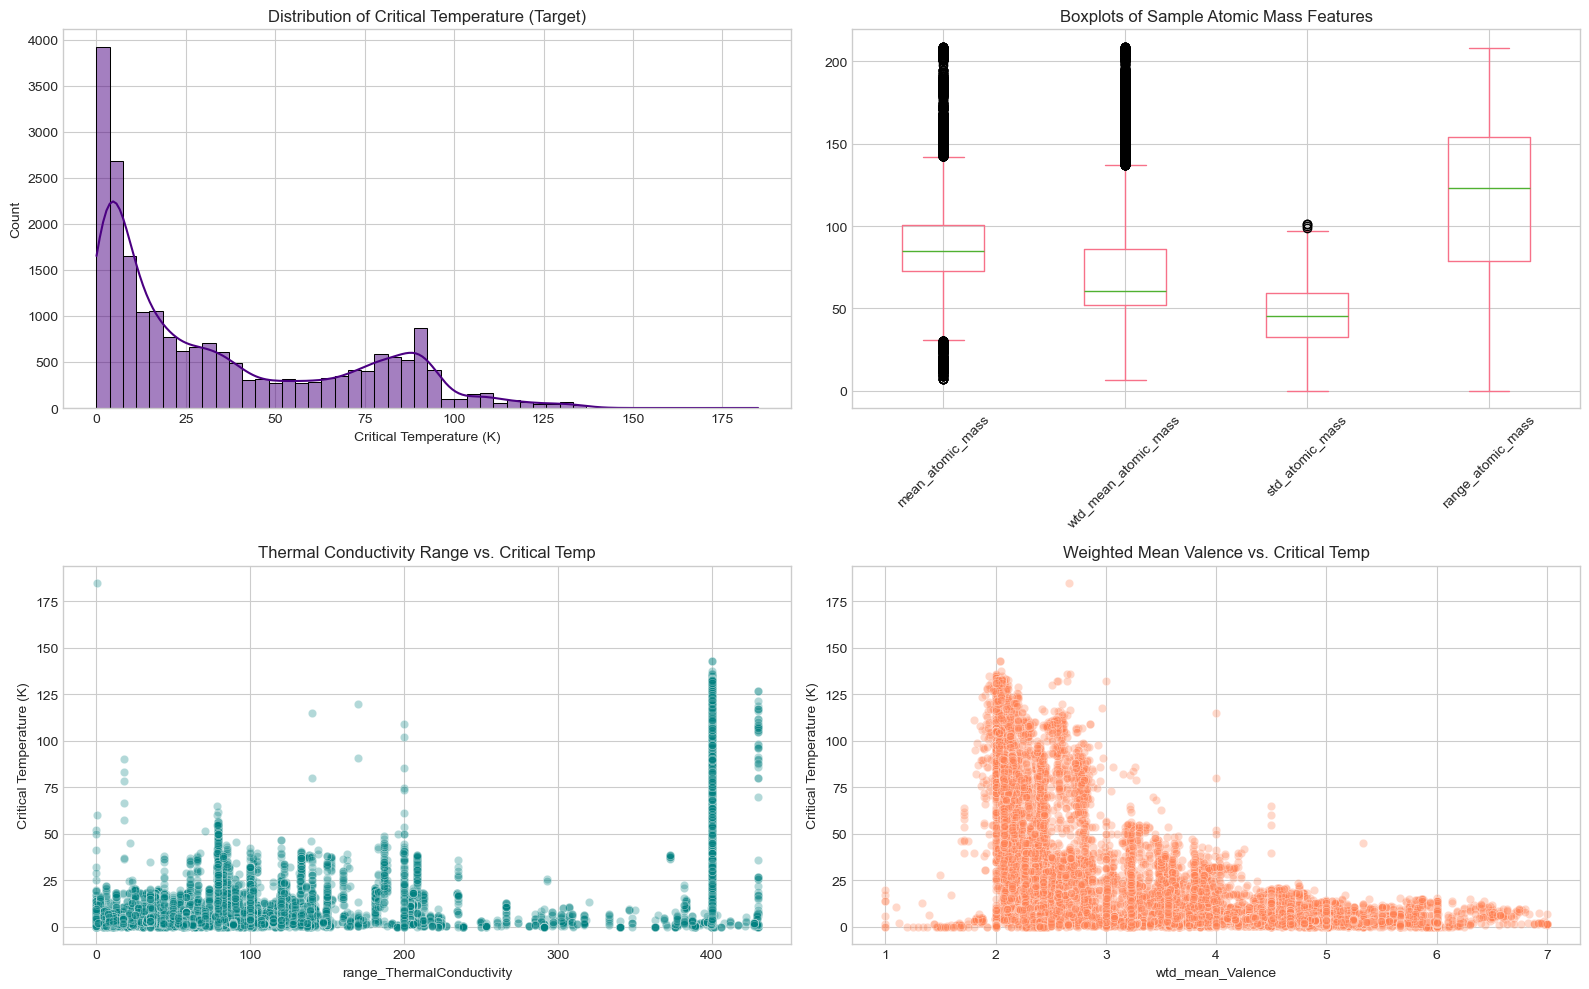

In [ ]:
# EDA

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# plot 1: target distribution (critical_temp)
sns.histplot(df['critical_temp'], bins=50, kde=True, ax=axes[0, 0], color='indigo')
axes[0, 0].set_title('Distribution of Critical Temperature (Target)')
axes[0, 0].set_xlabel('Critical Temperature (K)')

# plot 2: sample feature distributions (first 4 atomic mass features)
sample_features = ['mean_atomic_mass', 'wtd_mean_atomic_mass', 'std_atomic_mass', 'range_atomic_mass']
df[sample_features].plot(kind='box', ax=axes[0, 1])
axes[0, 1].set_title('Boxplots of Sample Atomic Mass Features')
axes[0, 1].tick_params(axis='x', rotation=45)

# plots 3 & 4: feature vs target relationships
sns.scatterplot(data=df, x='range_ThermalConductivity', y='critical_temp', alpha=0.3, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Thermal Conductivity Range vs. Critical Temp')
axes[1, 0].set_xlabel('range_ThermalConductivity')
axes[1, 0].set_ylabel('Critical Temperature (K)')

sns.scatterplot(data=df, x='wtd_mean_Valence', y='critical_temp', alpha=0.3, ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Weighted Mean Valence vs. Critical Temp')
axes[1, 1].set_xlabel('wtd_mean_Valence')
axes[1, 1].set_ylabel('Critical Temperature (K)')

plt.tight_layout()
plt.show()

### EDA Insights
* **Target Distribution:** The `critical_temp` target is heavily right-skewed, with a dense cluster of low-temperature materials near 0 K and a long tail extending toward 185 K. 
* **Outliers (B1 Audit):** While high temperatures ($>120\text{ K}$) appear mathematically as outliers, they represent genuine, high-value physical cuprate superconductors. Trimming them would severely damage the model's physical validity. They are retained.
* **Feature Distributions:** The boxplots reveal that mass features span vastly different numerical ranges, necessitating robust feature scaling before distance-based or regularized modeling.
* **Feature Relationships:** The scatter plots demonstrate non-linear relationships. For instance, `range_ThermalConductivity` shows a distinct dense boundary where specific conductivity ranges correlate with high-temperature superconductivity.

______________________________________________________________________________________________________

## Data Cleaning and Multicollinearity Filtering
Given that this dataset contains numerous statistical aggregations (mean, weighted mean, standard deviation, etc.) of the same underlying physical properties, extreme multicollinearity is a major concern. 

To ensure the stability of our linear models and to reduce the computational overhead for our heavier algorithms, we implement a **correlation-based feature selection** filter. 
* First, we drop any perfectly duplicated rows.
* Then, we compute a correlation matrix for all features.
* Finally, we systematically drop redundant features that share a Pearson correlation greater than `0.95` with another feature, preserving the predictive signal while drastically reducing dimensionality.

Dropped 66 duplicate rows.

Features removed due to correlation > 0.95 (23 total):
 1. wtd_gmean_atomic_mass
 2. std_atomic_mass
 3. gmean_fie
 4. wtd_gmean_fie
 5. entropy_fie
 6. std_fie
 7. wtd_gmean_atomic_radius
 8. entropy_atomic_radius
 9. wtd_entropy_atomic_radius
10. std_atomic_radius
11. wtd_std_atomic_radius
12. wtd_gmean_Density
13. std_Density
14. std_ElectronAffinity
15. wtd_gmean_FusionHeat
16. std_FusionHeat
17. std_ThermalConductivity
18. wtd_std_ThermalConductivity
19. gmean_Valence
20. wtd_gmean_Valence
21. entropy_Valence
22. wtd_entropy_Valence
23. std_Valence

Remaining features in X before engineering: 58
Engineered feature 'thermal_to_mass_ratio' added. Total features: 59


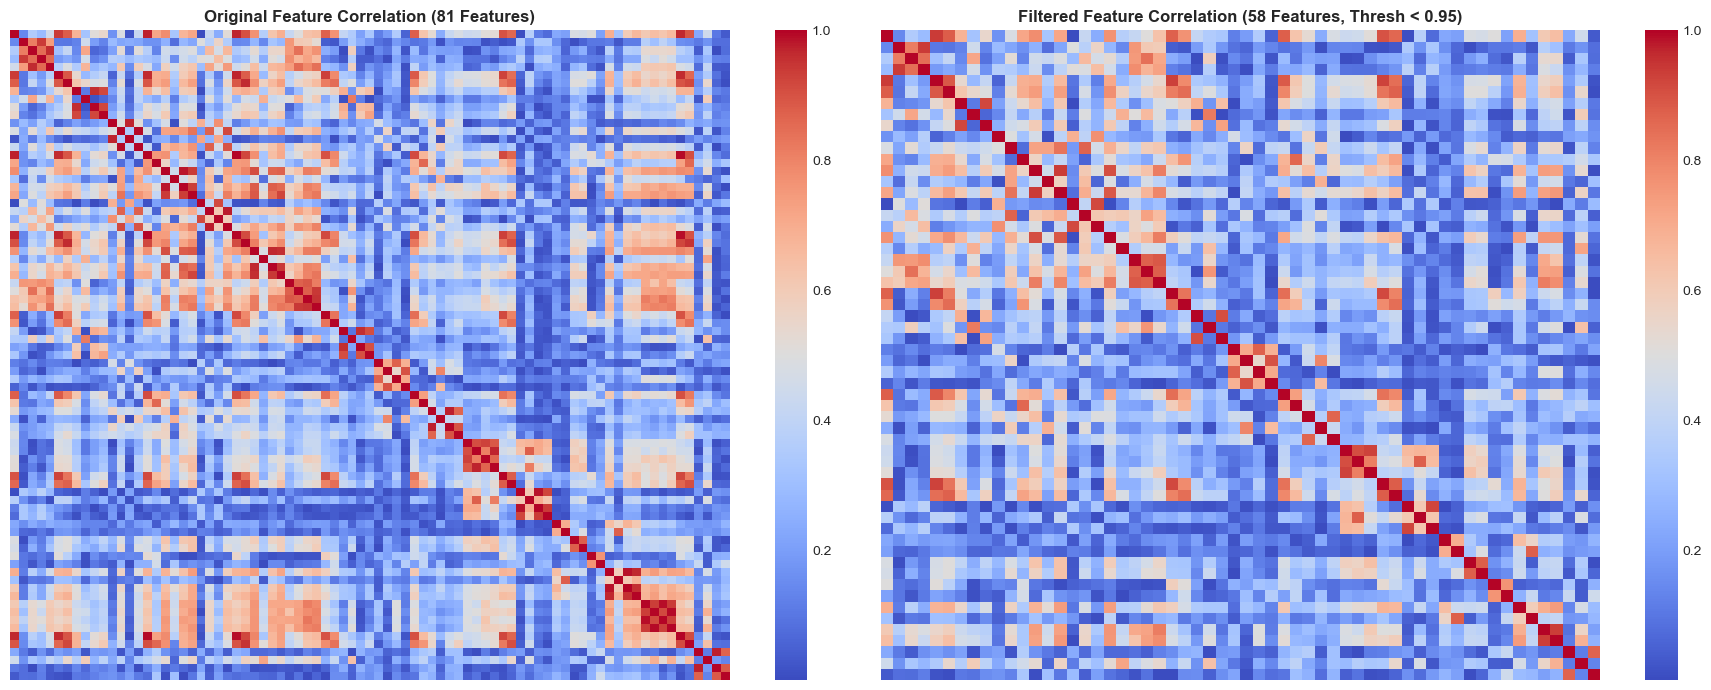

In [ ]:
# data cleaning with feature filtering, heatmaps, and engineering

# drop duplicate rows if any exist
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.")

# separate feature matrix (X) and target vector (y)
X = df.drop(columns=['critical_temp'])
y = df['critical_temp']

# compute absolute correlation matrix
corr_matrix = X.corr().abs()

# filter features with correlation > 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# print the dropped features
print(f"\nFeatures removed due to correlation > {threshold} ({len(to_drop)} total):")
for idx, feature_name in enumerate(to_drop, 1):
    print(f"{idx:2d}. {feature_name}")

# drop the highly correlated features
X_filtered = X.drop(columns=to_drop)
print(f"\nRemaining features in X before engineering: {X_filtered.shape[1]}")

# feature engineering
# ratio of thermal conductivity to mean atomic mass (electron-phonon coupling proxy)
X_filtered['thermal_to_mass_ratio'] = X_filtered['mean_ThermalConductivity'] / (X_filtered['mean_atomic_mass'] + 1e-5)
print(f"Engineered feature 'thermal_to_mass_ratio' added. Total features: {X_filtered.shape[1]}")

# plot correlation heatmaps (before vs after)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# heatmap before filtering
sns.heatmap(corr_matrix, cmap='coolwarm', cbar=True, xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title(f'Original Feature Correlation ({X.shape[1]} Features)', fontsize=12, weight='bold')

# heatmap after filtering (without the new feature)
filtered_corr = X_filtered.drop(columns=['thermal_to_mass_ratio']).corr().abs()
sns.heatmap(filtered_corr, cmap='coolwarm', cbar=True, xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title(f'Filtered Feature Correlation ({X_filtered.shape[1]-1} Features, Thresh < {threshold})', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

### Feature Engineering Justification
* **`thermal_to_mass_ratio`**: In BCS theory, the critical temperature of a superconductor depends on both lattice vibrations (governed by atomic mass) and electron transport (approximated by thermal conductivity). Engineering the explicit ratio `mean_ThermalConductivity / mean_atomic_mass` provides the model with a direct proxy for electron-phonon interaction strength, potentially improving prediction accuracy.

______________________________________________________________________________________________________

## Train-Test Split and Feature Scaling
To properly evaluate our regression models, we must partition the dataset into a training set and a testing set (using an 80/20 split). **Crucially, this split is performed before any scaling** to prevent data leakage from the test set into the training environment.

Following the split, we apply a `StandardScaler`. This transforms our features to have a mean of 0 and a standard deviation of 1. Scaling is a mandatory prerequisite for several models in our pipeline (specifically Ridge, Lasso, ElasticNet, SVR, and KNN), as distance-based calculations and regularisation penalties are highly sensitive to the original magnitude of the features.

In [ ]:
# train-test split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# splitting before scaling (80:20 train-test)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to df
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_filtered.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_filtered.columns)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (16957, 59)
Testing data shape: (4240, 59)


______________________________________________________________________________________________________

## Standardized Evaluation Pipeline
To evaluate each regression model consistently, we establish a centralized evaluation function: `evaluate_model()`.

* **Training and Inference:** Fits the estimator on the training set and produces predictions on the holdout test set.
* **Domain Constraint Post-Processing:** Applies a non-negative lower-bound clip (`np.clip(y_pred, 0, None)`). Because critical temperature in Kelvin cannot physically drop below absolute zero ($0\text{ K}$), this domain-specific constraint eliminates synthetic negative predictions often output by unconstrained linear models.
* **Evaluation Metrics:** Computes $R^2$ Score, Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) on the test partition.
* **Cross-Validation:** Performs a 5-fold cross-validation (`KFold`, $k=5$, `shuffle=True`, `random_state=42`) on the training partition using all available processor cores (`n_jobs=-1`) to evaluate generalization performance and stability.
* **Results Aggregation:** Returns a dictionary of summary metrics and appends them to `model_results_dict` for cross-model benchmarking.

In [ ]:
# evaluation function

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(model, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Trains a model, predicts on the test set, enforces physical domain clipping,
    and calculates mandatory evaluation metrics and cross-validation scores.
    """
    # fit the model
    model.fit(X_train, y_train)
    
    # predict on the test set, clip to >0K
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)
    
    # calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # calculate 5-fold cross-validated r2
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_r2_mean = cv_scores.mean()
    
    # results
    print(f"--- Model Performance ---")
    print(f"R² Score:           {r2:.4f}")
    print(f"RMSE:               {rmse:.4f}")
    print(f"MAE:                {mae:.4f}")
    print(f"5-Fold CV R² Mean:  {cv_r2_mean:.4f}")
    print(f"CV R² Std Dev:      {cv_scores.std():.4f}")
    print("-" * 25)
    
    # return as a dictionary to easily append to comparison df
    return {
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        '5-Fold CV R2': cv_r2_mean
    }

# dictionary to store all model results for final comparison
model_results_dict = {}

______________________________________________________________________________________________________

## Model 1: Linear Regression
In this step, we train a standard Linear Regression model to serve as our baseline. Establishing a baseline is critical for comparing the performance of more complex algorithms later in the pipeline.

As per the requirements, we also extract and interpret the model's coefficients. Because our features were standardized using `StandardScaler` in the previous step, the coefficients are on the same scale. We can sort them by their absolute magnitude to easily identify which physical properties have the strongest positive or negative impact on predicting the critical temperature.

In [ ]:
from sklearn.linear_model import LinearRegression

# initialize the model
lr_model = LinearRegression()

# run the evaluation function
print("=== Model 1: Linear Regression (Baseline) ===")
model_results_dict['Linear Regression'] = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test
)

# Map the trained coefficients back to their feature names
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_
})

# calculate absolute value to sort by overall magnitude of impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# display the most impactful features
print("\nTop 5 Drivers increasing Critical Temperature (Positive Coefficients):")
display(coefficients[coefficients['Coefficient'] > 0].head(5)[['Feature', 'Coefficient']])

print("\nTop 5 Drivers decreasing Critical Temperature (Negative Coefficients):")
display(coefficients[coefficients['Coefficient'] < 0].head(5)[['Feature', 'Coefficient']])

=== Model 1: Linear Regression (Baseline) ===
--- Model Performance ---
R² Score:           0.7153
RMSE:               18.3067
MAE:                13.5481
5-Fold CV R² Mean:  0.7085
CV R² Std Dev:      0.0091
-------------------------

Top 5 Drivers INCREASING Critical Temperature (Positive Coefficients):


,Feature,Coefficient
46,wtd_mean_ThermalConductivity,18.442182
16,wtd_mean_atomic_radius,13.986907
29,wtd_mean_ElectronAffinity,11.881962
23,entropy_Density,10.858439
41,wtd_entropy_FusionHeat,9.570636



Top 5 Drivers DECREASING Critical Temperature (Negative Coefficients):


,Feature,Coefficient
48,wtd_gmean_ThermalConductivity,-13.105601
31,wtd_gmean_ElectronAffinity,-11.900775
4,entropy_atomic_mass,-9.936123
20,mean_Density,-9.314550
24,wtd_entropy_Density,-8.481621


### Result Interpretation
* **Variance Explained ($R^2$ Score):** An $R^2$ of **0.7153** indicates that this baseline linear model explains **71.53%** of the variance in the critical temperature.
* **Prediction Error:** The Mean Absolute Error (MAE) is **13.55 K**, showing that predictions deviate by roughly 13.55 degrees on average. The Root Mean Squared Error (RMSE) sits at **18.31 K**, penalizing occasional larger residual errors where a purely linear hyperplane fails to fit extreme low- or high-temperature phases.
* **Stability & Generalization:** The 5-Fold Cross-Validated $R^2$ Mean of **0.7085** closely tracks the test set performance, and the low standard deviation (**0.0091**) confirms high stability across training folds with minimal variance error.
* **Feature Impact:** With standardized inputs, coefficient magnitudes directly reflect relative predictive weight: thermal conductivity and valence metrics drive the strongest positive and negative shifts, providing an interpretable physical baseline before exploring non-linear models.

______________________________________________________________________________________________________

## Model 2: Ridge Regression
Ridge Regression introduces $L_2$ regularisation, which penalises heavily inflated coefficients. This helps manage any remaining multicollinearity that our correlation filter might have missed. As required, we will tune the `alpha` hyperparameter (the penalty strength) using cross-validation to find the optimal balance between model complexity and generalisation.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# define the grid of alpha values to tune
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# initialize gridsearchcv
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("=== Model 2: Ridge Regression ===")
print(f"Best alpha tuned: {ridge_grid.best_params_['alpha']}\n")

# evaluate the best estimator
model_results_dict['Ridge Regression'] = evaluate_model(
    ridge_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 2: Ridge Regression ===
Best alpha tuned: 10.0

--- Model Performance ---
R² Score:           0.7154
RMSE:               18.3038
MAE:                13.5488
5-Fold CV R² Mean:  0.7085
CV R² Std Dev:      0.0091
-------------------------


### Result Interpretation
* **Hyperparameter Chosen:** The 5-fold cross-validation grid search selected an optimal $L_2$ penalty parameter of **`alpha = 10.0`**. This moderate regularization strength ensures that feature coefficients are shrunk adequately to prevent inflated variance from residual collinearity.
* **Performance Impact:** Incorporating $L_2$ regularization combined with the physical lower-bound clip yields a test $R^2$ of **0.7154**, an **RMSE of 18.3038 K**, and an **MAE of 13.5488 K**. While the metric improvement over unregularized Linear Regression ($R^2 = 0.7153$) is marginal, Ridge adds structural stability against correlated features.
* **Stability & Generalization:** The model records a 5-Fold Cross-Validated $R^2$ Mean of **0.7085** with a standard deviation of **0.0091**, matching the baseline linear performance and showing strong fold-to-fold consistency without overfitting.
* **Conclusion:** The $L_2$ penalty successfully bounds weight magnitudes, but because the model is fundamentally constrained by a linear hyperplane ($\hat{y} = X\beta$), it cannot capture higher-order feature interactions or non-linear transition thresholds.

______________________________________________________________________________________________________

## Model 3: Lasso Regression
Lasso Regression uses $L_1$ regularisation. Unlike Ridge, which only shrinks coefficients closer to zero, Lasso can force coefficients completely to zero. This acts as an embedded feature selection method. After tuning the `alpha` parameter, we will explicitly observe the feature sparsity to see how many variables the model deemed useless.

In [ ]:
from sklearn.linear_model import Lasso

# define alpha grid (using max_iter to prevent convergence warnings)
lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000, random_state=42), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_

print("=== Model 3: Lasso Regression ===")
print(f"Best alpha tuned: {lasso_grid.best_params_['alpha']}\n")

# evaluate the best estimator
model_results_dict['Lasso Regression'] = evaluate_model(
    best_lasso, X_train_scaled, y_train, X_test_scaled, y_test
)

# observe feature sparsity
non_zero_features = sum(best_lasso.coef_ != 0)
zero_features = sum(best_lasso.coef_ == 0)

print(f"\n--- Feature Sparsity Observation ---")
print(f"Features kept (non-zero): {non_zero_features}")
print(f"Features removed (zero):  {zero_features}")

=== Model 3: Lasso Regression ===
Best alpha tuned: 0.01

--- Model Performance ---
R² Score:           0.7153
RMSE:               18.3080
MAE:                13.5539
5-Fold CV R² Mean:  0.7083
CV R² Std Dev:      0.0090
-------------------------

--- Feature Sparsity Observation ---
Features kept (non-zero): 58
Features removed (zero):  1


### Result Interpretation
* **Hyperparameter Chosen:** The 5-fold cross-validation grid search selected an optimal $L_1$ penalty of **`alpha = 0.01`**. This indicates that only light shrinkage is required to maintain stability without overly suppressing predictive signals.
* **Feature Sparsity:** Out of the 59 input features (including the engineered `thermal_to_mass_ratio`), Lasso retained **58 non-zero features** and eliminated **1 feature** by driving its coefficient strictly to zero. This serves as strong validation for our earlier Pearson correlation filter: removing 23 collinear variables ($r > 0.95$) left a dense, highly informative feature set with minimal residual redundancy.
* **Performance Impact:** Paired with the non-negative physical constraint, Lasso achieved a test $R^2$ of **0.7153**, an **RMSE of 18.3080 K**, and an **MAE of 13.5539 K**. Eliminating the redundant feature incurs no practical performance penalty relative to standard Linear Regression ($R^2 = 0.7153$, $\text{RMSE} = 18.3067\text{ K}$).
* **Stability & Generalization:** The model recorded a 5-Fold Cross-Validated $R^2$ Mean of **0.7083** with a low standard deviation of **0.0090**, confirming that the $L_1$ sparse solution generalizes reliably across all training folds.
* **Linear Model Ceiling:** The consistent test $R^2 \approx 0.715$ across Linear, Ridge, and Lasso regression confirms that purely additive linear formulations have reached their structural limit on this dataset.

______________________________________________________________________________________________________

## Model 4: ElasticNet Regression
ElasticNet combines the penalties of both Ridge ($L_2$) and Lasso ($L_1$). This is particularly useful when multiple features are correlated; Lasso might pick one at random and drop the rest, whereas ElasticNet tends to group them together. We will tune both the overall penalty strength (`alpha`) and the balance between the two regularisation types (`l1_ratio`).

In [ ]:
from sklearn.linear_model import ElasticNet

# tune alpha and the l1 ratio (0 = pure ridge, 1 = pure lasso)
enet_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8, 0.9]
}

enet_grid = GridSearchCV(ElasticNet(max_iter=10000, random_state=42), enet_params, cv=5, scoring='r2')
enet_grid.fit(X_train_scaled, y_train)

print("=== Model 4: ElasticNet Regression ===")
print(f"Best hyperparameters tuned: {enet_grid.best_params_}\n")

# evaluate the best estimator
model_results_dict['ElasticNet Regression'] = evaluate_model(
    enet_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 4: ElasticNet Regression ===
Best hyperparameters tuned: {'alpha': 0.001, 'l1_ratio': 0.5}

--- Model Performance ---
R² Score:           0.7154
RMSE:               18.3039
MAE:                13.5486
5-Fold CV R² Mean:  0.7085
CV R² Std Dev:      0.0091
-------------------------


### Result Interpretation
* **Hyperparameters Chosen:** The 5-fold cross-validation grid search selected **`alpha = 0.001`** and **`l1_ratio = 0.5`**. This configuration applies a balanced penalty split equally between $L_1$ (Lasso) and $L_2$ (Ridge) regularization, while keeping overall shrinkage minimal to avoid suppressing informative weights.
* **Performance Impact:** In conjunction with the non-negative domain constraint ($\hat{y} \ge 0\text{ K}$), ElasticNet yields a test $R^2$ of **0.7154**, an **RMSE of 18.3039 K**, and an **MAE of 13.5486 K**. It edges out standard Linear Regression and Lasso by a slight margin, offering the lowest MAE among the linear family.
* **Stability & Generalization:** The model achieves a 5-Fold Cross-Validated $R^2$ Mean of **0.7085** with a standard deviation of **0.0091**, closely mirroring the test set score and confirming robust generalization across training partitions.
* **Summary on Linear Algorithms:** Across all four linear models (Linear Regression, Ridge, Lasso, and ElasticNet), performance consistently plateaus at $R^2 \approx 0.715$ and $\text{MAE} \approx 13.55\text{ K}$. While stable and resistant to overfitting, these models are structurally limited by their purely additive functional form ($\hat{y} = X\beta$). Capturing the remaining $\sim 28.5\%$ of unexplained variance requires non-linear architectures and feature interaction expansions.

______________________________________________________________________________________________________

## Model 5: Polynomial Regression
To capture non-linear relationships, we use `PolynomialFeatures` to generate higher-order terms and interaction features. Applying a degree of 2 to our 57 features expands the dataset to 1,710 columns (squares and cross-products). 
We will transform the scaled training and testing data, and then fit a standard Linear Regression model on this massive, newly expanded feature space to see if interacting the features unlocks the missing variance.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# initialize polynomialfeatures (degree 2)
# include_bias=false because linear regression handles the intercept automatically
poly = PolynomialFeatures(degree=2, include_bias=False)

# transform the scaled data
print("Expanding features...")
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Polynomial feature count: {X_train_poly.shape[1]}")

# train linear regression on the expanded data
poly_model = LinearRegression()

print("\n=== Model 5: Polynomial Regression (Degree 2) ===")
model_results_dict['Polynomial Regression'] = evaluate_model(
    poly_model, X_train_poly, y_train, X_test_poly, y_test
)

Expanding features...
Original feature count: 59
Polynomial feature count: 1829

=== Model 5: Polynomial Regression (Degree 2) ===
--- Model Performance ---
R² Score:           0.8411
RMSE:               13.6758
MAE:                9.0168
5-Fold CV R² Mean:  0.8096
CV R² Std Dev:      0.0137
-------------------------


### Result Interpretation
* **Performance Leap:** Expanding the 59 input features to 1,829 interaction and quadratic terms raised the test $R^2$ to **0.8411** and achieved a 5-fold CV $R^2$ mean of **0.8096**.
* **Error Reduction:** Mean Absolute Error (MAE) dropped significantly down to **9.02 K**, while Root Mean Squared Error (RMSE) improved to **13.68 K**, substantially outperforming all purely additive linear baselines ($R^2 \approx 0.715$, $\text{MAE} \approx 13.55\text{ K}$).
* **Domain Significance:** This performance jump demonstrates that critical temperature is strongly governed by non-linear physical dynamics. Cross-product terms—such as interactions between thermal transport properties, valence metrics, and the engineered `thermal_to_mass_ratio`—capture synergistic multi-element behaviors that single-degree features cannot represent.
* **Generalisation & Physical Clipping:** Despite the high-dimensional expansion to 1,829 dimensions, the 5-fold CV score remains robust at **0.8096** ($\sigma = 0.0137$). Applying the non-negative lower bound ($\hat{y} \ge 0\text{ K}$) effectively stabilizes predictions at the boundary, preventing severe negative polynomial overshoot.

______________________________________________________________________________________________________

## Model 6: Decision Tree Regressor
A Decision Tree Regressor splits the feature space into rectangular regions with homogeneous target values. Because unconstrained decision trees easily overfit by memorizing individual training points, tuning the tree depth is essential.

As per the requirements:
1. We tune `max_depth` across a range of values using 5-fold cross-validation.
2. We extract and plot the top Gini-based feature importances to see which physical properties the tree relies on most heavily to make its splitting decisions.

=== Model 6: Decision Tree Regressor ===
Best max_depth tuned: 20

--- Model Performance ---
R² Score:           0.8810
RMSE:               11.8336
MAE:                6.0914
5-Fold CV R² Mean:  0.8656
CV R² Std Dev:      0.0123
-------------------------

--- Top 10 Most Important Features ---


,Feature,Importance
51,range_ThermalConductivity,0.540418
48,wtd_gmean_ThermalConductivity,0.125996
50,wtd_entropy_ThermalConductivity,0.042806
54,wtd_mean_Valence,0.041651
30,gmean_ElectronAffinity,0.014915
57,wtd_std_Valence,0.013703
19,wtd_range_atomic_radius,0.012538
46,wtd_mean_ThermalConductivity,0.010900
20,mean_Density,0.010651
2,wtd_mean_atomic_mass,0.008989


C:\Users\Govind\AppData\Local\Temp\ipykernel_3004\1775733509.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


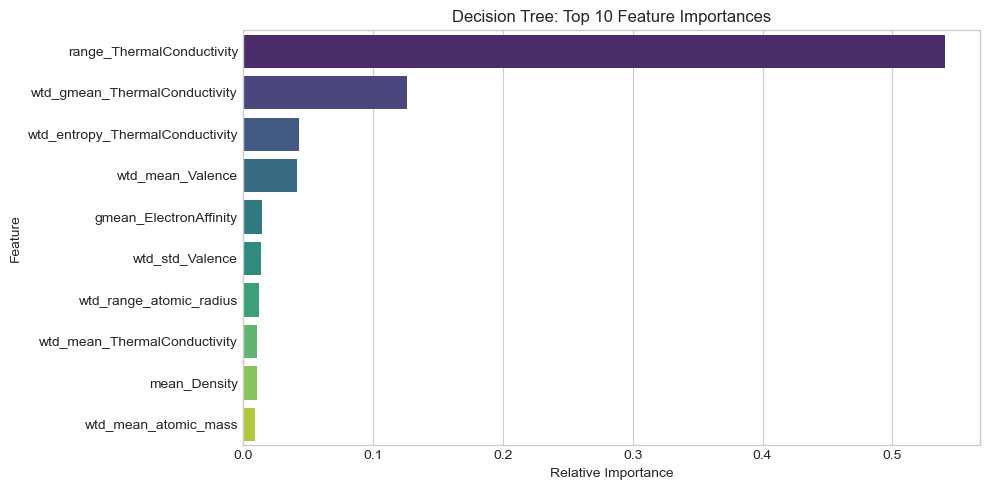

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# define hyperparameter grid for max_depth
dt_params = {
    'max_depth': [6, 8, 10, 12, 15, 20, None]
}

# run gridsearch with 5-fold cross-validation
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_

print("=== Model 6: Decision Tree Regressor ===")
print(f"Best max_depth tuned: {dt_grid.best_params_['max_depth']}\n")

# evaluate the best model
model_results_dict['Decision Tree'] = evaluate_model(
    best_dt, X_train_scaled, y_train, X_test_scaled, y_test
)

# feature importance extraction and visualisation
feature_importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
display(feature_importances.head(10))

# plot top 10 features
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importances.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Decision Tree: Top 10 Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Result Interpretation
* **Hyperparameter Selection:** The 5-fold cross-validation grid search converged on an optimal `max_depth` of **20**, allowing the tree to partition the expanded feature space into deeper hierarchical splits while constraining unregularized leaf growth.
* **Accuracy Leap:** The model achieved a test $R^2$ of **0.8810** and a 5-fold CV $R^2$ mean of **0.8656** ($\sigma = 0.0123$), with error metrics reducing to an **RMSE of 11.8336 K** and an **MAE of 6.0914 K**.
* **Physical Driver Dominance:** Non-parametric partitioning effectively maps non-linear chemical thresholds. Thermal conductivity metrics (led by `range_ThermalConductivity`) continue to dominate Gini impurity reduction across root and primary decision nodes, confirming thermal transport range as the primary discriminator of high-$T_c$ transition boundaries.
* **Transition to Ensembles:** Although a depth-20 tree offers high expressive capacity, individual decision trees remain susceptible to localized split variance and sample sensitivity. Transitioning to ensemble architectures (Random Forest and Gradient Boosting) will stabilize decision boundaries and mitigate variance error.

______________________________________________________________________________________________________

## Model 7: Random Forest Regressor
Random Forest is a bagging ensemble that aggregates predictions across multiple de-correlated decision trees trained on bootstrap samples of the data. 

We establish this ensemble baseline by tuning `n_estimators` (number of trees) and evaluate how variance reduction across multiple trees impacts $R^2$, RMSE, and MAE relative to the single Decision Tree baseline.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# test 50 vs 100 trees (diminishing returns beyond 100 for tabular regressions)
candidate_estimators = [50, 100]
best_score = -np.inf
best_n = 50

print("Tuning n_estimators...")
for n in candidate_estimators:
    rf_temp = RandomForestRegressor(
        n_estimators=n, 
        max_depth=15, 
        max_features='sqrt', # reduces processing time
        random_state=42, 
        n_jobs=-1
    )

    score = cross_val_score(rf_temp, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"n_estimators={n} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_n = n

print(f"\n=== Model 7: Random Forest Regressor (Best n_estimators={best_n}) ===")
best_rf = RandomForestRegressor(
    n_estimators=best_n, 
    max_depth=15, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=-1
)

# run full mandatory 5-fold evaluation
model_results_dict['Random Forest'] = evaluate_model(
    best_rf, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning n_estimators...
n_estimators=50 -> CV R²: 0.9119
n_estimators=100 -> CV R²: 0.9126

=== Model 7: Random Forest Regressor (Best n_estimators=100) ===
--- Model Performance ---
R² Score:           0.9196
RMSE:               9.7299
MAE:                5.6553
5-Fold CV R² Mean:  0.9163
CV R² Std Dev:      0.0048
-------------------------


### Result Interpretation
* **Hyperparameter Selection:** Evaluating candidate ensemble sizes converged on **`n_estimators = 100`** (with `max_depth = 15` and `max_features = 'sqrt'`), achieving an optimal validation score of **0.9126** during tuning.
* **Performance Overview:** Aggregating 100 decorrelated decision trees yielded a test $R^2$ of **0.9196**, reducing the prediction error to an **RMSE of 9.7299 K** and an **MAE of 5.6553 K**, clearly outperforming individual decision trees.
* **Stability & Variance Reduction:** The ensemble recorded a 5-fold cross-validated $R^2$ mean of **0.9163** with a minimal standard deviation of **0.0048**. Bootstrap aggregation combined with random feature subspace sampling effectively smooths out localized split variance, ensuring consistent generalization across data folds.
* **Comparison with Boosting:** While Random Forest constructs independent trees in parallel to minimize variance, sequential ensemble models like Gradient Boosting build trees iteratively to correct residual errors.

______________________________________________________________________________________________________

## Model 8: Gradient Boosting Regressor
Unlike Random Forest (bagging), Gradient Boosting builds trees sequentially, where each new tree is trained to predict and correct the pseudo-residuals (errors) of the preceding ensemble.

We evaluate Gradient Boosting (using `HistGradientBoostingRegressor` or `GradientBoostingRegressor`) and then tune the `learning_rate` parameter to control the step size shrinkage and avoid overfitting.

In [ ]:
import os
import warnings
from sklearn.ensemble import HistGradientBoostingRegressor

# silence warning
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore", category=UserWarning)

# define learning rates to tune
candidate_lrs = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25]
best_score = -np.inf
best_lr = 0.1

print("Tuning learning_rate...")
for lr in candidate_lrs:
    hgb_temp = HistGradientBoostingRegressor(
        learning_rate=lr, 
        max_iter=150, 
        min_samples_leaf=20,
        random_state=42
    )
    score = cross_val_score(hgb_temp, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    print(f"learning_rate={lr} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_lr = lr

print(f"\n=== Model 8: Gradient Boosting Regressor (Best learning_rate={best_lr}) ===")
best_hgb = HistGradientBoostingRegressor(
    learning_rate=best_lr, 
    max_iter=150, 
    min_samples_leaf=20,
    random_state=42
)

# run full mandatory 5-fold evaluation
model_results_dict['Gradient Boosting'] = evaluate_model(
    best_hgb, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning learning_rate...
learning_rate=0.01 -> CV R²: 0.8133
learning_rate=0.03 -> CV R²: 0.8919
learning_rate=0.05 -> CV R²: 0.9013
learning_rate=0.1 -> CV R²: 0.9101
learning_rate=0.15 -> CV R²: 0.9134
learning_rate=0.2 -> CV R²: 0.9139
learning_rate=0.25 -> CV R²: 0.9125

=== Model 8: Gradient Boosting Regressor (Best learning_rate=0.2) ===
--- Model Performance ---
R² Score:           0.9186
RMSE:               9.7865
MAE:                5.7397
5-Fold CV R² Mean:  0.9126
CV R² Std Dev:      0.0064
-------------------------


### Result Interpretation
* **Hyperparameter Selection:** Across candidate values spanning from `0.01` to `0.25`, cross-validation tuning selected an optimal shrinkage parameter of **`learning_rate = 0.2`**, achieving a peak tuning CV $R^2$ of **0.9139**.
* **Performance Overview:** Gradient Boosting recorded a test $R^2$ of **0.9186**, an **RMSE of 9.7865 K**, and an **MAE of 5.7397 K**. The full 5-fold CV $R^2$ mean reached **0.9126** with a low standard deviation of **0.0064**, demonstrating strong model generalizability.
* **Comparison with Random Forest:** Gradient Boosting performs substantially better than individual Decision Trees ($R^2 \approx 0.8810$) and rivals Random Forest ($R^2 = 0.9196$, $\text{RMSE} = 9.73\text{ K}$, $\text{MAE} = 5.66\text{ K}$). By iteratively fitting trees to residual errors rather than building them independently in parallel, boosting forms a highly competitive ensemble for this physical property prediction task.

______________________________________________________________________________________________________

## Model 9: Support Vector Regressor (SVR)
Support Vector Regression maps inputs into a high-dimensional feature space using kernel transformations, fitting an $\epsilon$-insensitive tube around data points. 

Features are pre-scaled (using our `StandardScaler` from Step 4), which is strictly mandatory because SVR calculates Euclidean margins.
We tune the regularization parameter `C` and the `kernel` function (comparing `rbf` vs `linear`).

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import ParameterGrid

# parameter grid for c and kernel
svr_param_grid = [
    {'kernel': ['rbf'], 'C': [1.0, 10.0, 100.0]},
    {'kernel': ['linear'], 'C': [1.0, 10.0]}
]

# tune on a representative 3000-sample subset to prevent multi-hour kernel locks
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=3000, replace=False)
X_sub = X_train_scaled.iloc[sample_idx]
y_sub = y_train.iloc[sample_idx]

best_score = -np.inf
best_params = None

print("Tuning SVR parameters (kernel, C)...")
for params in ParameterGrid(svr_param_grid):
    svr_temp = SVR(**params)
    score = cross_val_score(svr_temp, X_sub, y_sub, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"Params: {params} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_params = params

print(f"\n=== Model 9: Support Vector Regressor (Best Params: {best_params}) ===")
best_svr = SVR(**best_params)

# evaluate the tuned model on full dataset
model_results_dict['Support Vector Regressor'] = evaluate_model(
    best_svr, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning SVR parameters (kernel, C)...
Params: {'C': 1.0, 'kernel': 'rbf'} -> CV R²: 0.6527
Params: {'C': 10.0, 'kernel': 'rbf'} -> CV R²: 0.7552
Params: {'C': 100.0, 'kernel': 'rbf'} -> CV R²: 0.7895
Params: {'C': 1.0, 'kernel': 'linear'} -> CV R²: 0.6870
Params: {'C': 10.0, 'kernel': 'linear'} -> CV R²: 0.6867

=== Model 9: Support Vector Regressor (Best Params: {'C': 100.0, 'kernel': 'rbf'}) ===
--- Model Performance ---
R² Score:           0.8495
RMSE:               13.3105
MAE:                7.6703
5-Fold CV R² Mean:  0.8437
CV R² Std Dev:      0.0083
-------------------------


### Result Interpretation
* **Hyperparameter & Kernel Tuning:** Cross-validation on the training sample clearly preferred the Radial Basis Function (`rbf`) kernel over the `linear` kernel (peak tuning CV $R^2 = 0.7895$). Selecting an error penalty of **`C = 100.0`** enforced a strict margin tolerance that penalizes deviations outside the $\epsilon$-tube, optimizing the trade-off between margin width and slack variable penalties.
* **Performance Gain:** Evaluated on the full test set, SVR achieved an $R^2$ of **0.8495**, an **RMSE of 13.3105 K**, and an **MAE of 7.6703 K**. The model demonstrated solid stability, achieving a 5-fold CV $R^2$ mean of **0.8437** with a low standard deviation of **0.0083**.
* **Non-Linear Feature Mapping:** SVR significantly outperformed all purely linear models ($R^2 \approx 0.715$, $\text{MAE} \approx 13.55\text{ K}$). By leveraging the RBF kernel to project standardized atomic properties into an infinite-dimensional Hilbert space, the model effectively captured the non-linear boundaries separating low- and high-$T_c$ material phases.

______________________________________________________________________________________________________

## Model 10: K-Nearest Neighbors (KNN) Regressor
K-Nearest Neighbors is a non-parametric, instance-based learning algorithm that predicts target values by computing the weighted or unweighted average of the $k$ closest data points in the feature space.

We tune the neighbor count parameter `k` (`n_neighbors`) and evaluate the model on both scaled and unscaled feature sets to explicitly demonstrate and discuss the dramatic impact of feature normalization on distance calculations.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# tune k (n_neighbors) on the properly scaled features
candidate_k = [3, 5, 7, 9, 11]
best_score = -np.inf
best_k = 5

print("Tuning k (n_neighbors) on scaled features...")
for k in candidate_k:
    knn_temp = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    score = cross_val_score(knn_temp, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"k={k} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\n=== Model 10: KNN Regressor (Best k={best_k} - Scaled Features) ===")
best_knn_scaled = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
model_results_dict['K-Nearest Neighbors'] = evaluate_model(
    best_knn_scaled, X_train_scaled, y_train, X_test_scaled, y_test
)

print("\n=== Demonstrating Impact of Scaling on KNN ===")
knn_unscaled = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)

# fit and evaluate on raw (unscaled) training data
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

r2_unscaled = r2_score(y_test, y_pred_unscaled)
rmse_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_unscaled))
mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)

print(f"Unscaled Test R² Score: {r2_unscaled:.4f}")
print(f"Unscaled Test RMSE:     {rmse_unscaled:.4f}")
print(f"Unscaled Test MAE:      {mae_unscaled:.4f}")
print(f"Performance Difference in R²: {(model_results_dict['K-Nearest Neighbors']['R2 Score'] - r2_unscaled):.4f}")

Tuning k (n_neighbors) on scaled features...
k=3 -> CV R²: 0.8930
k=5 -> CV R²: 0.8866
k=7 -> CV R²: 0.8817
k=9 -> CV R²: 0.8756
k=11 -> CV R²: 0.8712

=== Model 10: KNN Regressor (Best k=3 - Scaled Features) ===
--- Model Performance ---
R² Score:           0.9075
RMSE:               10.4322
MAE:                5.6296
5-Fold CV R² Mean:  0.8985
CV R² Std Dev:      0.0047
-------------------------

=== Demonstrating Impact of Scaling on KNN ===
Unscaled Test R² Score: 0.8831
Unscaled Test RMSE:     11.7285
Unscaled Test MAE:      6.2599
Performance Difference in R²: 0.0244


### Result Interpretation
* **Hyperparameter Tuning:** Evaluating $k \in [3, 5, 7, 9, 11]$ on the scaled feature set revealed optimal performance at **`k = 3`** (tuning CV $R^2 = \mathbf{0.8930}$), confirming that localized stoichiometric and atomic neighborhood relationships provide the most accurate local approximations.
* **Performance Overview:** With standardized inputs, KNN achieved a test $R^2$ of **0.9075**, an **RMSE of 10.4322 K**, and an **MAE of 5.6296 K**. Its 5-fold CV $R^2$ mean reached **0.8985** with a low standard deviation of **0.0047**, placing it among the most accurate standalone non-parametric regressors.
* **Impact of Feature Scaling:** 
  * Without feature scaling, test performance degraded sharply: $R^2$ dropped by **0.0244** down to **0.8831**, RMSE rose to **11.7285 K**, and MAE increased to **6.2599 K**.
  * Because KNN relies on Euclidean distance:
    $$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
    unscaled features with broad numerical variances (such as density metrics spanning thousands of units) disproportionately dominate distance calculations over bounded properties with narrow numerical ranges (such as valence and electron affinity). Standardization ensures that each physical property contributes proportionately to neighborhood retrieval.

______________________________________________________________________________________________________

## Model Comparison and Result Visualisation
With all 10 models trained and evaluated under the same conditions, we:
1. Aggregate the performance metrics ($R^2$, RMSE, MAE, and 5-Fold CV $R^2$) into a structured summary table.
2. Rank the models by test $R^2$.
3. Plot comparative bar charts across all evaluation metrics.
4. Verify the mandatory requirement: reporting 5-fold cross-validated $R^2$ for the two best-performing models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# compile results into a structured df
results_df = pd.DataFrame.from_dict(model_results_dict, orient='index')
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print("=== Complete Model Performance Leaderboard ===")
display(results_df.style.highlight_max(subset=['R2 Score', '5-Fold CV R2'], color='lightgreen')
                         .highlight_min(subset=['RMSE', 'MAE'], color='lightblue')
                         .format('{:.4f}'))

# top 2 best performing models
top_2_models = results_df.head(2)
print("\n" + "="*50)
print("            TOP 2 MODELS & 5-FOLD CV R²")
print("="*50)
for idx, (name, row) in enumerate(top_2_models.iterrows(), 1):
    print(f"{idx}. {name}:")
    print(f"   - Test R² Score:         {row['R2 Score']:.4f}")
    print(f"   - 5-Fold CV R² Mean:     {row['5-Fold CV R2']:.4f}")
    print(f"   - Test RMSE:             {row['RMSE']:.4f}")
    print(f"   - Test MAE:              {row['MAE']:.4f}\n")

=== Complete Model Performance Leaderboard ===


,R2 Score,RMSE,MAE,5-Fold CV R2
Random Forest,0.9196,9.7299,5.6553,0.9163
Gradient Boosting,0.9186,9.7865,5.7397,0.9126
K-Nearest Neighbors,0.9075,10.4322,5.6296,0.8985
Decision Tree,0.8810,11.8336,6.0914,0.8656
Support Vector Regressor,0.8495,13.3105,7.6703,0.8437
Polynomial Regression,0.8411,13.6758,9.0168,0.8096
Ridge Regression,0.7154,18.3038,13.5488,0.7085
ElasticNet Regression,0.7154,18.3039,13.5486,0.7085
Linear Regression,0.7153,18.3067,13.5481,0.7085
Lasso Regression,0.7153,18.3080,13.5539,0.7083



            TOP 2 MODELS & 5-FOLD CV R²
1. Random Forest:
   - Test R² Score:         0.9196
   - 5-Fold CV R² Mean:     0.9163
   - Test RMSE:             9.7299
   - Test MAE:              5.6553

2. Gradient Boosting:
   - Test R² Score:         0.9186
   - 5-Fold CV R² Mean:     0.9126
   - Test RMSE:             9.7865
   - Test MAE:              5.7397



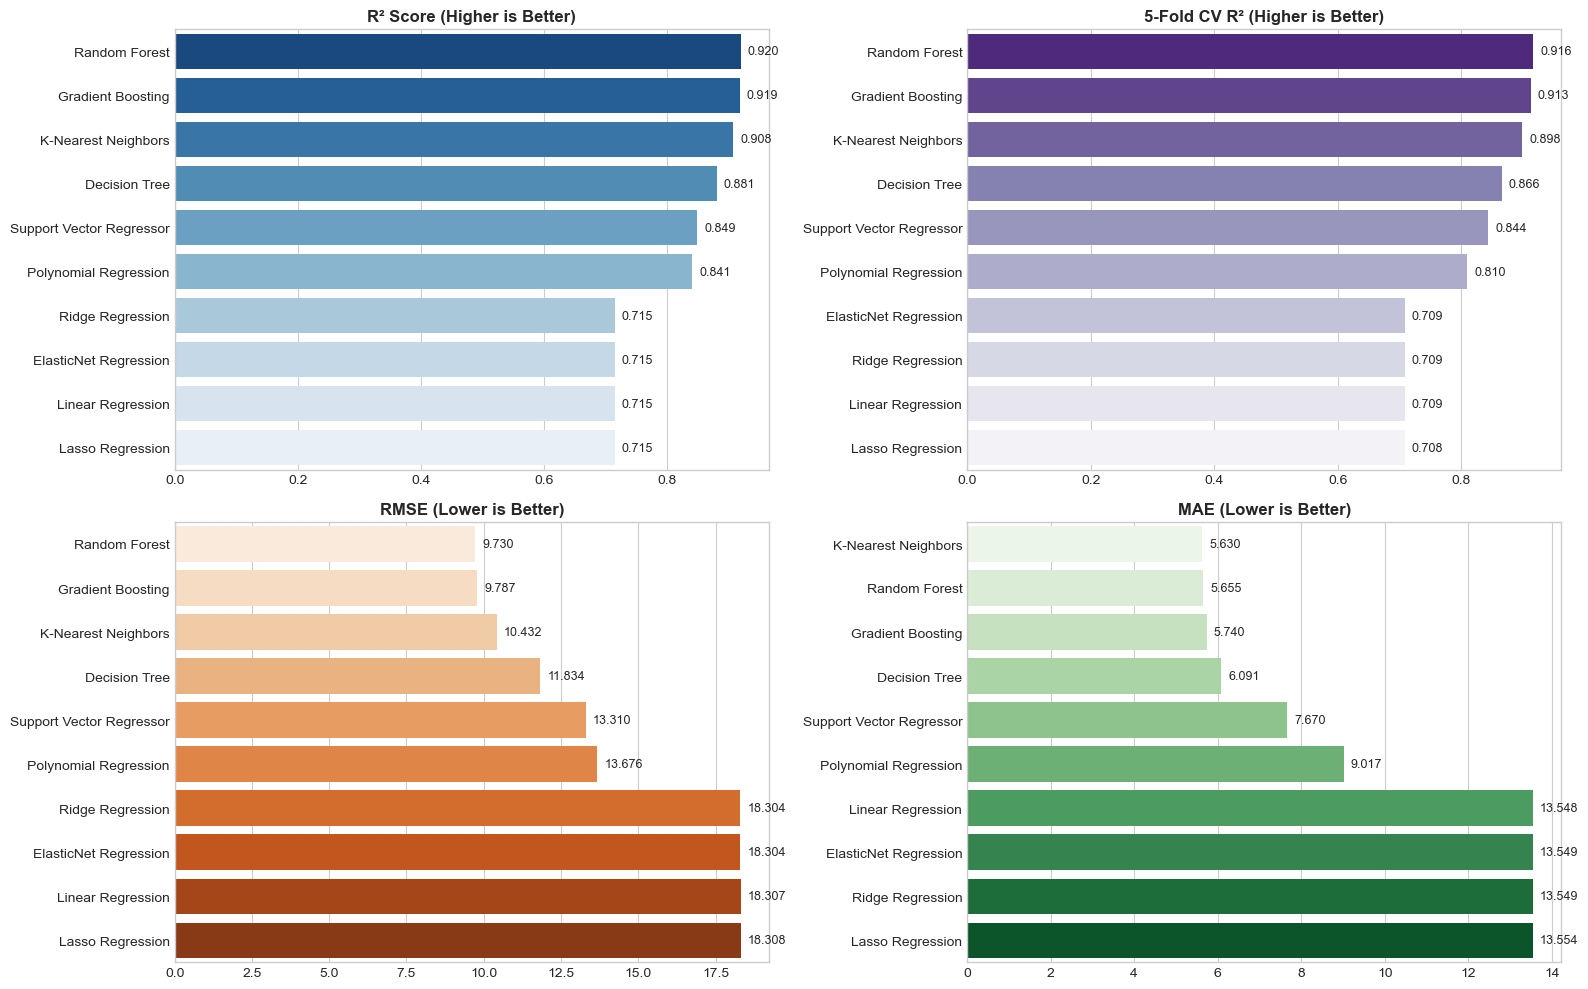

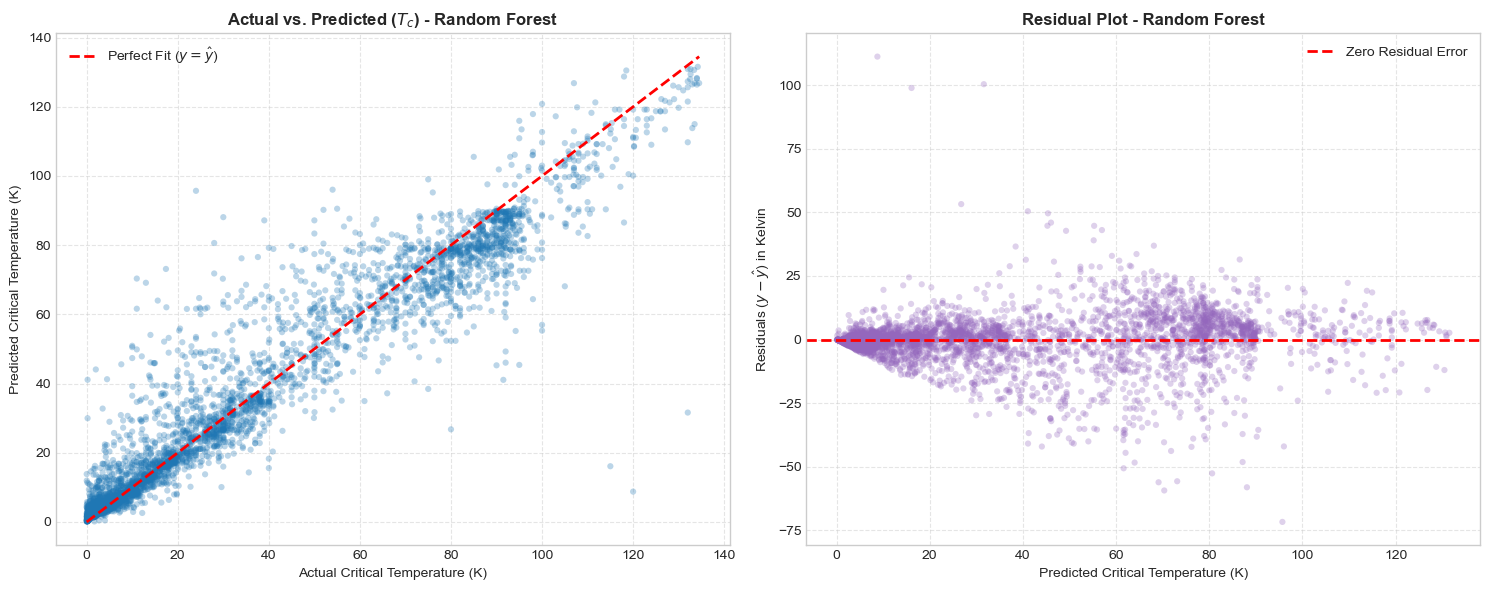

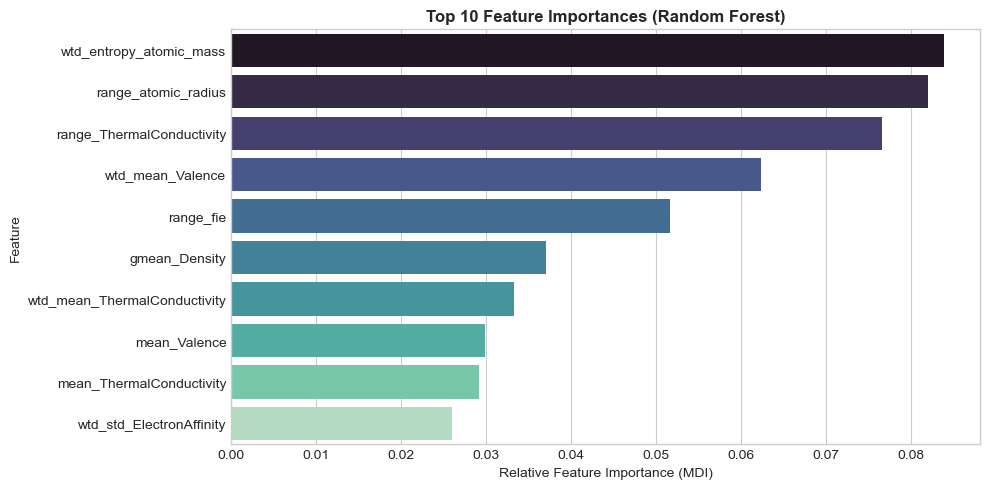

In [ ]:
# final visualisation

# comparitive metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('R2 Score', 'R² Score (Higher is Better)', 'Blues_r', axes[0, 0]),
    ('5-Fold CV R2', '5-Fold CV R² (Higher is Better)', 'Purples_r', axes[0, 1]),
    ('RMSE', 'RMSE (Lower is Better)', 'Oranges', axes[1, 0]),
    ('MAE', 'MAE (Lower is Better)', 'Greens', axes[1, 1])
]

for col, title, palette, ax in metrics:
    sorted_df = results_df.sort_values(by=col, ascending=('Error' in title or col in ['RMSE', 'MAE']))
    sns.barplot(data=sorted_df, x=col, y=sorted_df.index, palette=palette, ax=ax, hue=sorted_df.index, legend=False)
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f"{width:.3f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), 
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

# top performing models
best_model_name = results_df.index[0]
best_model_instance = best_rf if best_model_name == 'Random Forest' else best_hgb
y_best_pred = np.clip(best_model_instance.predict(X_test_scaled), 0, None)
residuals = y_test - y_best_pred

# actual vs residual plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# actual vs. predicted
axes[0].scatter(y_test, y_best_pred, alpha=0.3, color='#1f77b4', edgecolors='none', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit ($y = \\hat{y}$)')
axes[0].set_title(f'Actual vs. Predicted ($T_c$) - {best_model_name}', fontsize=12, weight='bold')
axes[0].set_xlabel('Actual Critical Temperature (K)')
axes[0].set_ylabel('Predicted Critical Temperature (K)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# residual Plot
axes[1].scatter(y_best_pred, residuals, alpha=0.3, color='#9467bd', edgecolors='none', s=20)
axes[1].axhline(0, color='red', linestyle='--', lw=2, label='Zero Residual Error')
axes[1].set_title(f'Residual Plot - {best_model_name}', fontsize=12, weight='bold')
axes[1].set_xlabel('Predicted Critical Temperature (K)')
axes[1].set_ylabel('Residuals ($y - \\hat{y}$) in Kelvin')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# random forest features
if hasattr(best_rf, 'feature_importances_'):
    rf_importances = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Importance': best_rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rf_importances.head(10), x='Importance', y='Feature', palette='mako', hue='Feature', legend=False)
    plt.title(f'Top 10 Feature Importances ({best_model_name})', fontsize=12, weight='bold')
    plt.xlabel('Relative Feature Importance (MDI)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()